In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

# 한글 폰트
!apt-get -qq install fonts-nanum

import matplotlib.font_manager as fm

fm.fontManager.addfont(
    '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 118332 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
신설 = pd.read_csv(
    "/content/drive/MyDrive/MBCA/1차 팀 프로젝트/데이터 파일/폐업 및 신설/부산_행정구별_월별_신설법인_202201-202607.csv",
    encoding= "utf-8-sig")

폐업 = pd.read_csv(
    "/content/drive/MyDrive/MBCA/1차 팀 프로젝트/데이터 파일/폐업 및 신설/21-25전국_부산_폐업수.csv",
    encoding= "utf-8-sig")

display(신설.head())
display(폐업.head())

,연월,행정구,신설법인수
0,202201,강서구,59
1,202201,금정구,28
2,202201,기장군,27
3,202201,남구,36
4,202201,동구,20


,연도,지역구분,지역명,폐업사업자_총계,법인,개인사업자,일반사업자,간이사업자,면세사업자
0,2025,전국,전국,975681,85270,890411,483210,313861,93340
1,2025,부산전체,부산,56651,4177,52474,28514,18942,5018
2,2025,부산구군,강서구,3850,408,3442,2310,834,298
3,2025,부산구군,금정구,3365,244,3121,1706,1127,288
4,2025,부산구군,기장군,3200,268,2932,1537,1079,316


In [ ]:
신설['연도'] = 신설['연월'] // 100
신설['월'] = 신설['연월'] % 100

신설_분석 = 신설[
    신설['연도'].between(2022, 2025)
].copy()

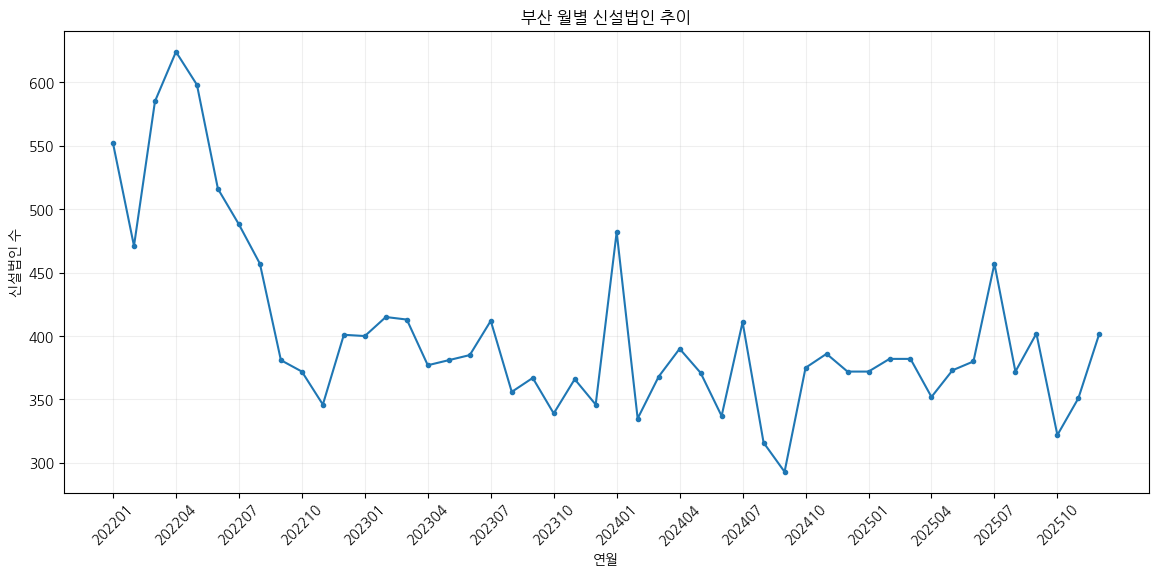

In [ ]:
월별_신설 = (
    신설_분석
    .groupby('연월', as_index=False)
    ['신설법인수']
    .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    월별_신설['연월'].astype(str),
    월별_신설['신설법인수'],
    marker='o',
    markersize=3
)

plt.xticks(
    range(0, len(월별_신설), 3),
    월별_신설['연월'].astype(str)[::3],
    rotation=45
)

plt.title('부산 월별 신설법인 추이')
plt.xlabel('연월')
plt.ylabel('신설법인 수')
plt.grid(alpha=0.2)

plt.show()

In [ ]:
신설_연간 = (
    신설_분석
    .groupby(
        ['연도', '행정구'],
        as_index=False
    )
    ['신설법인수']
    .sum()
)

신설_연간.head()

,연도,행정구,신설법인수
0,2022,강서구,604
1,2022,금정구,294
2,2022,기장군,284
3,2022,남구,390
4,2022,동구,251


In [ ]:
폐업_구군 = 폐업[
    (폐업['지역구분'] == '부산구군') &
    (폐업['연도'].between(2022, 2025))
].copy()

폐업_구군 = 폐업_구군[
    [
        '연도',
        '지역명',
        '법인',
        '폐업사업자_총계',
        '개인사업자'
    ]
]

폐업_구군 = 폐업_구군.rename(
    columns={
        '지역명': '행정구',
        '법인': '법인폐업수',
        '폐업사업자_총계': '전체폐업수',
        '개인사업자': '개인사업자폐업수'
    }
)

In [ ]:
분석 = pd.merge(
    신설_연간,
    폐업_구군,
    on=['연도', '행정구'],
    how='inner'
)

print(분석.shape)

분석.head()

(64, 6)


,연도,행정구,신설법인수,법인폐업수,전체폐업수,개인사업자폐업수
0,2022,강서구,604,351,3367,3016
1,2022,금정구,294,198,3324,3126
2,2022,기장군,284,203,3177,2974
3,2022,남구,390,210,3481,3271
4,2022,동구,251,176,2075,1899


In [ ]:
분석['신설대비폐업비'] = (
    분석['법인폐업수']
    / 분석['신설법인수']
)

In [ ]:
분석['신설폐업격차'] = (
    분석['신설법인수']
    - 분석['법인폐업수']
)

In [ ]:
분석['활력균형지수'] = (
    (분석['신설법인수'] - 분석['법인폐업수'])
    /
    (분석['신설법인수'] + 분석['법인폐업수'])
)

In [ ]:
# 지역 규모 효과 확인
for year in range(2022, 2026):

    temp = 분석[
        분석['연도'] == year
    ]

    r, p = pearsonr(
        temp['신설법인수'],
        temp['법인폐업수']
    )

    print(
        year,
        f'Pearson r = {r:.3f}',
        f'p = {p:.5f}'
    )

    # r = 높은 양의 관계 / but 신설이 많으니 폐업이 많다 X
    # 규모가 큰 상권은 신설도 많고 폐업도 많다

2022 Pearson r = 0.974 p = 0.00000
2023 Pearson r = 0.964 p = 0.00000
2024 Pearson r = 0.938 p = 0.00000
2025 Pearson r = 0.893 p = 0.00000


In [ ]:
# 증감률 비교 필요
분석 = 분석.sort_values(
    ['행정구', '연도']
)

분석['신설증감률'] = (
    분석
    .groupby('행정구')['신설법인수']
    .pct_change()
    * 100
)

분석['법인폐업증감률'] = (
    분석
    .groupby('행정구')['법인폐업수']
    .pct_change()
    * 100
)

In [ ]:
# 상관분석
증감분석 = 분석.dropna(
    subset=[
        '신설증감률',
        '법인폐업증감률'
    ]
)

r, p = pearsonr(
    증감분석['신설증감률'],
    증감분석['법인폐업증감률']
)

rho, sp = spearmanr(
    증감분석['신설증감률'],
    증감분석['법인폐업증감률']
)

print(
    f'Pearson r = {r:.3f}, p = {p:.4f}'
)

print(
    f'Spearman rho = {rho:.3f}, p = {sp:.4f}'
)

# 절대 규모는 강한 상관관계를 보이나, 신설 증가율과 폐업 증가율은 사실상 서로 관계가 없다.

Pearson r = 0.026, p = 0.8595
Spearman rho = 0.123, p = 0.4037


In [ ]:
# 폐업압력지수 생성
분석['폐업압력지수'] = (
    분석['법인폐업증감률']
    - 분석['신설증감률']
)

# ex) 신설 -10%, 폐업 +20% = 폐업압력 +30
# ex) 신설 +20%, 폐업 +5% = 폐업압력 =15
# 값이 클수록 '신설 성장에 비해 폐업이 악화되는 수치'

In [ ]:
문제지역_2025 = (
    분석[
        분석['연도'] == 2025
    ]
    .sort_values(
        '폐업압력지수',
        ascending=False
    )
)

문제지역_2025[
    [
        '행정구',
        '신설법인수',
        '법인폐업수',
        '신설증감률',
        '법인폐업증감률',
        '폐업압력지수',
        '신설대비폐업비',
        '활력균형지수'
    ]
]

,행정구,신설법인수,법인폐업수,신설증감률,법인폐업증감률,폐업압력지수,신설대비폐업비,활력균형지수
57,사하구,234,235,-7.142857,35.057471,42.200328,1.004274,-0.002132
51,남구,287,326,-10.591900,30.923695,41.515595,1.135889,-0.063622
61,영도구,72,79,-28.000000,-1.250000,26.750000,1.097222,-0.046358
62,중구,158,195,6.756757,28.289474,21.532717,1.234177,-0.104816
63,해운대구,651,588,-10.943912,7.495430,18.439342,0.903226,0.050847
60,연제구,231,260,-8.695652,8.333333,17.028986,1.125541,-0.059063
49,금정구,233,244,5.429864,16.746411,11.316547,1.047210,-0.023061
52,동구,184,196,-16.363636,-10.091743,6.271893,1.065217,-0.031579
50,기장군,250,268,-7.407407,-2.898551,4.508857,1.072000,-0.034749
58,서구,81,104,10.958904,11.827957,0.869053,1.283951,-0.124324


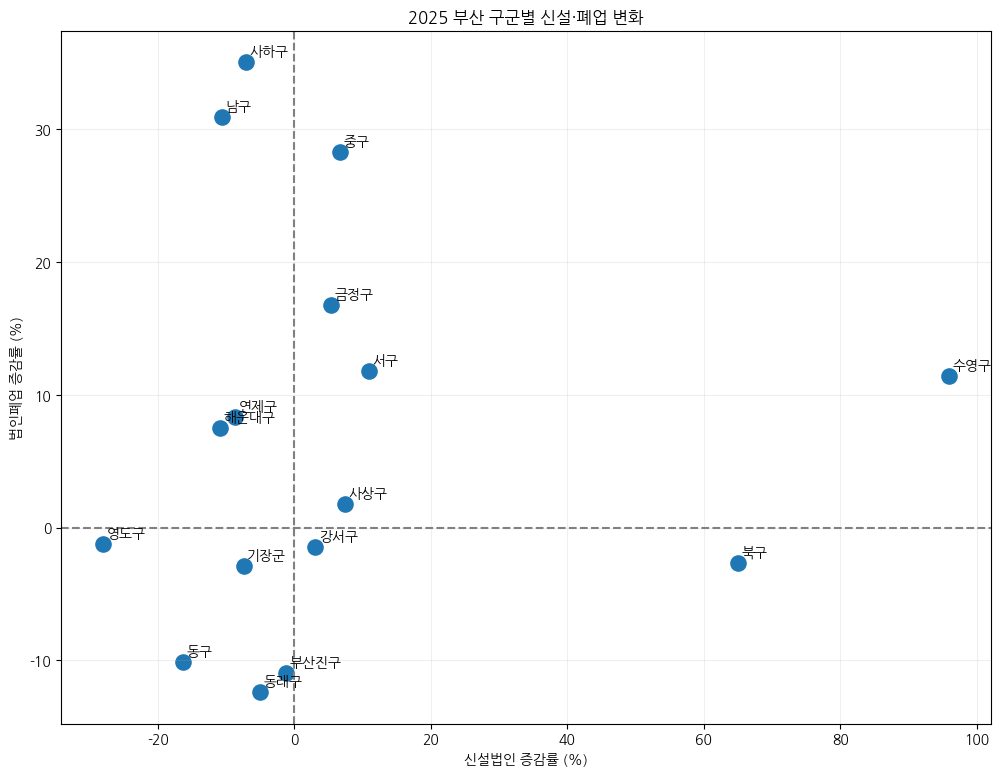

In [ ]:
temp = 분석[
    분석['연도'] == 2025
].dropna()

plt.figure(figsize=(12, 9))

plt.scatter(
    temp['신설증감률'],
    temp['법인폐업증감률'],
    s=120
)

plt.axvline(
    0,
    color='gray',
    linestyle='--'
)

plt.axhline(
    0,
    color='gray',
    linestyle='--'
)

for _, row in temp.iterrows():

    plt.text(
        row['신설증감률'] + 0.5,
        row['법인폐업증감률'] + 0.5,
        row['행정구']
    )

plt.xlabel('신설법인 증감률 (%)')
plt.ylabel('법인폐업 증감률 (%)')

plt.title(
    '2025 부산 구군별 신설·폐업 변화'
)

plt.grid(alpha=0.2)

plt.show()

In [ ]:
분석[
    분석['연도'] == 2025
].sort_values(
    '신설대비폐업비',
    ascending=False
)[
    [
        '행정구',
        '신설법인수',
        '법인폐업수',
        '신설대비폐업비'
    ]
]

,행정구,신설법인수,법인폐업수,신설대비폐업비
58,서구,81,104,1.283951
62,중구,158,195,1.234177
51,남구,287,326,1.135889
60,연제구,231,260,1.125541
61,영도구,72,79,1.097222
50,기장군,250,268,1.072000
52,동구,184,196,1.065217
54,부산진구,417,438,1.050360
49,금정구,233,244,1.047210
57,사하구,234,235,1.004274


In [ ]:
분석['법인폐업증감률'] = (
    분석.groupby('행정구')['법인폐업수']
    .pct_change() * 100
)

분석['개인폐업증감률'] = (
    분석.groupby('행정구')['개인사업자폐업수']
    .pct_change() * 100
)

분석['전체폐업증감률'] = (
    분석.groupby('행정구')['전체폐업수']
    .pct_change() * 100
)

In [ ]:
분석

,연도,행정구,신설법인수,법인폐업수,전체폐업수,개인사업자폐업수,신설대비폐업비,신설폐업격차,활력균형지수,신설증감률,법인폐업증감률,폐업압력지수,개인폐업증감률,전체폐업증감률
0,2022,강서구,604,351,3367,3016,0.581126,253,0.264921,NaN,NaN,NaN,NaN,NaN
16,2023,강서구,533,353,3755,3402,0.662289,180,0.203160,-11.754967,0.569801,12.324767,12.798408,11.523612
32,2024,강서구,552,414,4123,3709,0.750000,138,0.142857,3.564728,17.280453,13.715725,9.024103,9.800266
48,2025,강서구,569,408,3850,3442,0.717047,161,0.164790,3.079710,-1.449275,-4.528986,-7.198706,-6.621392
1,2022,금정구,294,198,3324,3126,0.673469,96,0.195122,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,2025,중구,158,195,1746,1551,1.234177,-37,-0.104816,6.756757,28.289474,21.532717,-9.720605,-6.631016
15,2022,해운대구,1061,608,6921,6313,0.573044,453,0.271420,NaN,NaN,NaN,NaN,NaN
31,2023,해운대구,697,664,8005,7341,0.952654,33,0.024247,-34.307257,9.210526,43.517784,16.283859,15.662477
47,2024,해운대구,731,547,7301,6754,0.748290,184,0.143975,4.878049,-17.620482,-22.498531,-7.996186,-8.794503


In [23]:
from google.colab import files
uploaded = files.upload()

Saving 법인_기준_폐업_신설_데이터_분석.ipynb to 법인_기준_폐업_신설_데이터_분석.ipynb


In [24]:
!jupyter nbconvert --to html "법인_기준_폐업_신설_데이터_분석.ipynb"

[NbConvertApp] Converting notebook 법인_기준_폐업_신설_데이터_분석.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 485449 bytes to 법인_기준_폐업_신설_데이터_분석.html


In [26]:
files.download("법인_기준_폐업_신설_데이터_분석.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
방문 = pd.read_csv("/content/drive/MyDrive/MBCA/1차 팀 프로젝트/데이터 파일/방문자 수/부산시_행정구별_월별_방문자수_통합_202301_202606_v2 복사.csv")
방문

,연월,행정구,외국인 방문자 수,외지인 방문자 수,현지인 방문자 수,전체 수
0,202301,강서구,116492,3381336,2415172,5913000
1,202301,금정구,11984,2425745,3791823,6229552
2,202301,기장군,44563,3759980,2862748,6667291
3,202301,남구,46794,2470836,4333217,6850847
4,202301,동구,37029,2645570,1401824,4084423
...,...,...,...,...,...,...
667,202606,수영구,288084,3358530,3182098,6828712
668,202606,연제구,133626,2830006,2354390,5318022
669,202606,영도구,336973,1570653,2009266,3916892
670,202606,중구,389117,3286448,1249178,4924743


In [28]:
방문['외부방문자 수'] = (
    방문['외지인 방문자 수']
    + 방문['외국인 방문자 수']
)

방문.head()

,연월,행정구,외국인 방문자 수,외지인 방문자 수,현지인 방문자 수,전체 수,외부방문자 수
0,202301,강서구,116492,3381336,2415172,5913000,3497828
1,202301,금정구,11984,2425745,3791823,6229552,2437729
2,202301,기장군,44563,3759980,2862748,6667291,3804543
3,202301,남구,46794,2470836,4333217,6850847,2517630
4,202301,동구,37029,2645570,1401824,4084423,2682599


In [30]:
방문['외국인비중'] = (
    방문['외국인 방문자 수']
    / 방문['외부방문자 수']
    * 100
)

방문['연도'] = 방문['연월'] // 100

In [32]:
방문_연간 = (
    방문[
        방문['연도'].between(2023, 2025)
    ]
    .groupby(
        ['연도', '행정구'],
        as_index=False
    )
    .agg({
        '외부방문자 수': 'sum',
        '외지인 방문자 수': 'sum',
        '외국인 방문자 수': 'sum',
        '현지인 방문자 수': 'sum',
        '전체 수': 'sum'
    })
)

방문_연간.tail()

,연도,행정구,외부방문자 수,외지인 방문자 수,외국인 방문자 수,현지인 방문자 수,전체 수
43,2025,수영구,42992660,41449363,1543297,35562930,78555590
44,2025,연제구,33047255,32669658,377597,27017599,60064854
45,2025,영도구,20996440,18824561,2171879,22489609,43486049
46,2025,중구,43540457,40783846,2756611,14353420,57893877
47,2025,해운대구,77164505,72850929,4313576,89321976,166486481


In [33]:
방문_연간['외부방문비중'] = (
    방문_연간['외부방문자 수']
    / 방문_연간['전체 수']
    * 100
)

방문_연간['외국인비중'] = (
    방문_연간['외국인 방문자 수']
    / 방문_연간['외부방문자 수']
    * 100
)

In [34]:
통합 = pd.merge(
    분석,
    방문_연간,
    on=['연도', '행정구'],
    how='inner'
)

print(통합.shape)

통합.head()

(48, 21)


,연도,행정구,신설법인수,법인폐업수,전체폐업수,개인사업자폐업수,신설대비폐업비,신설폐업격차,활력균형지수,신설증감률,...,폐업압력지수,개인폐업증감률,전체폐업증감률,외부방문자 수,외지인 방문자 수,외국인 방문자 수,현지인 방문자 수,전체 수,외부방문비중,외국인비중
0,2023,강서구,533,353,3755,3402,0.662289,180,0.203160,-11.754967,...,12.324767,12.798408,11.523612,42675732,39971333,2704399,30254373,72930105,58.515934,6.337089
1,2024,강서구,552,414,4123,3709,0.750000,138,0.142857,3.564728,...,13.715725,9.024103,9.800266,45097425,41067382,4030043,30329530,75426955,59.789534,8.936304
2,2025,강서구,569,408,3850,3442,0.717047,161,0.164790,3.079710,...,-4.528986,-7.198706,-6.621392,50128291,44556991,5571300,33443717,83572008,59.982155,11.114083
3,2023,금정구,229,216,3645,3429,0.943231,13,0.029213,-22.108844,...,31.199753,9.692898,9.657040,30000875,29679346,321529,44717001,74717876,40.152205,1.071732
4,2024,금정구,221,209,3503,3294,0.945701,12,0.027907,-3.493450,...,0.252709,-3.937008,-3.895748,30198106,29811315,386791,43610259,73808365,40.914205,1.280845


In [35]:
통합 = 통합.sort_values(
    ['행정구', '연도']
)

방문지표 = [
    '외부방문자 수',
    '외지인 방문자 수',
    '외국인 방문자 수',
    '현지인 방문자 수'
]

for col in 방문지표:

    통합[f'{col}_증감률'] = (
        통합
        .groupby('행정구')[col]
        .pct_change()
        * 100
    )

In [36]:
통합['전체폐업증감률'] = (
    통합
    .groupby('행정구')['전체폐업수']
    .pct_change()
    * 100
)

통합['개인폐업증감률'] = (
    통합
    .groupby('행정구')['개인사업자폐업수']
    .pct_change()
    * 100
)

통합['법인폐업증감률'] = (
    통합
    .groupby('행정구')['법인폐업수']
    .pct_change()
    * 100
)

통합['신설증감률'] = (
    통합
    .groupby('행정구')['신설법인수']
    .pct_change()
    * 100
)

In [37]:
상관분석 = 통합.dropna(
    subset=[
        '외부방문자 수_증감률',
        '전체폐업증감률'
    ]
)

In [38]:
from scipy.stats import pearsonr, spearmanr

r, p = pearsonr(
    상관분석['외부방문자 수_증감률'],
    상관분석['전체폐업증감률']
)

print(f'Pearson r = {r:.3f}')
print(f'p-value = {p:.4f}')

Pearson r = -0.189
p-value = 0.2993


In [39]:
rho, p2 = spearmanr(
    상관분석['외부방문자 수_증감률'],
    상관분석['전체폐업증감률']
)

print(f'Spearman rho = {rho:.3f}')
print(f'p-value = {p2:.4f}')

Spearman rho = -0.193
p-value = 0.2904


In [40]:
targets = [
    '전체폐업증감률',
    '개인폐업증감률',
    '법인폐업증감률',
    '신설증감률'
]

결과 = []

for target in targets:

    temp = 통합.dropna(
        subset=[
            '외부방문자 수_증감률',
            target
        ]
    )

    r, p = pearsonr(
        temp['외부방문자 수_증감률'],
        temp[target]
    )

    결과.append({
        '비교지표': target,
        '상관계수': r,
        'p-value': p
    })

상관결과 = pd.DataFrame(결과)

상관결과

,비교지표,상관계수,p-value
0,전체폐업증감률,-0.189364,0.299262
1,개인폐업증감률,-0.193239,0.289299
2,법인폐업증감률,0.031413,0.864484
3,신설증감률,0.169080,0.354918


In [41]:
방문유형 = [
    '외지인 방문자 수_증감률',
    '외국인 방문자 수_증감률',
    '현지인 방문자 수_증감률',
    '외부방문자 수_증감률'
]

targets = [
    '전체폐업증감률',
    '법인폐업증감률',
    '신설증감률'
]

결과 = []

for x in 방문유형:

    for y in targets:

        temp = 통합.dropna(
            subset=[x, y]
        )

        r, p = pearsonr(
            temp[x],
            temp[y]
        )

        결과.append({
            '방문지표': x,
            '상권지표': y,
            'Pearson_r': round(r, 3),
            'p_value': round(p, 4)
        })

상관매트릭스 = pd.DataFrame(결과)

상관매트릭스

,방문지표,상권지표,Pearson_r,p_value
0,외지인 방문자 수_증감률,전체폐업증감률,-0.266,0.1406
1,외지인 방문자 수_증감률,법인폐업증감률,0.038,0.8381
2,외지인 방문자 수_증감률,신설증감률,0.165,0.3677
3,외국인 방문자 수_증감률,전체폐업증감률,0.066,0.7190
4,외국인 방문자 수_증감률,법인폐업증감률,-0.283,0.1164
5,외국인 방문자 수_증감률,신설증감률,0.060,0.7437
6,현지인 방문자 수_증감률,전체폐업증감률,-0.064,0.7280
7,현지인 방문자 수_증감률,법인폐업증감률,0.194,0.2872
8,현지인 방문자 수_증감률,신설증감률,0.167,0.3608
9,외부방문자 수_증감률,전체폐업증감률,-0.189,0.2993


In [42]:
temp = 통합[
    통합['연도'] == 2025
].dropna(
    subset=[
        '외부방문자 수_증감률',
        '전체폐업증감률'
    ]
)

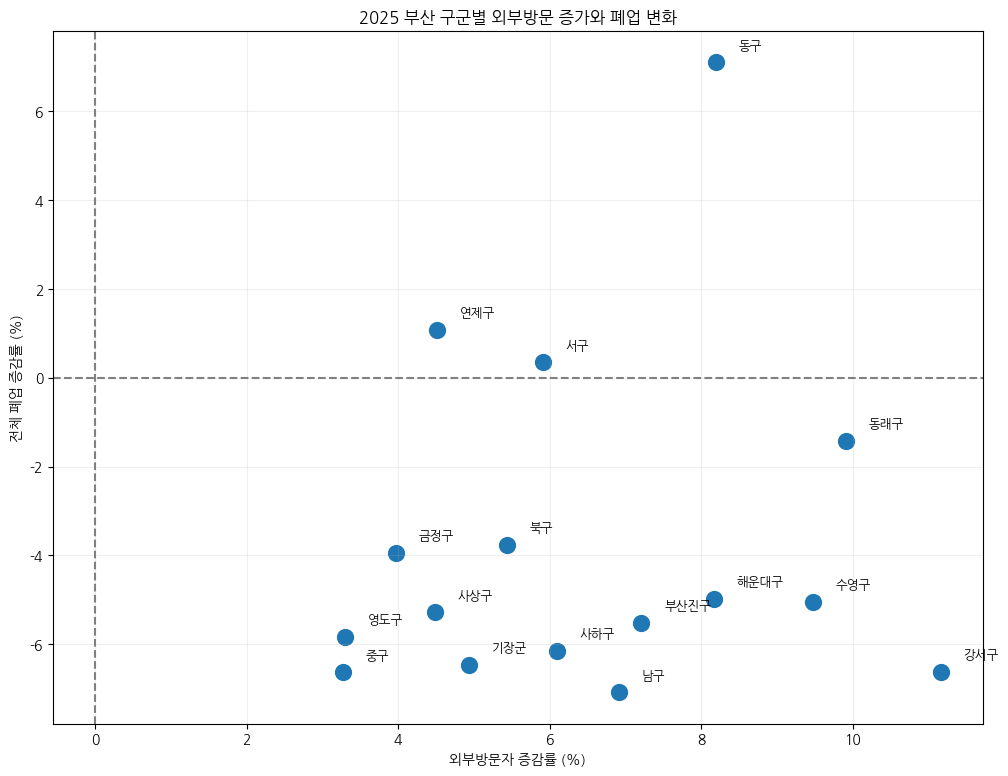

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

plt.scatter(
    temp['외부방문자 수_증감률'],
    temp['전체폐업증감률'],
    s=130
)

plt.axvline(
    0,
    color='gray',
    linestyle='--'
)

plt.axhline(
    0,
    color='gray',
    linestyle='--'
)

for _, row in temp.iterrows():

    plt.text(
        row['외부방문자 수_증감률'] + 0.3,
        row['전체폐업증감률'] + 0.3,
        row['행정구'],
        fontsize=9
    )

plt.xlabel('외부방문자 증감률 (%)')
plt.ylabel('전체 폐업 증감률 (%)')

plt.title(
    '2025 부산 구군별 외부방문 증가와 폐업 변화'
)

plt.grid(alpha=0.2)

plt.show()

In [44]:
def 유형분류(row):

    관광 = row['외부방문자 수_증감률']
    신설 = row['신설증감률']
    폐업 = row['전체폐업증감률']

    if pd.isna(관광) or pd.isna(신설) or pd.isna(폐업):
        return '분류불가'

    if 관광 > 0 and 신설 > 0 and 폐업 <= 0:
        return '관광수혜 성장형'

    elif 관광 > 0 and 신설 < 0 and 폐업 > 0:
        return '관광-상권 괴리형'

    elif 관광 > 0 and 신설 > 0 and 폐업 > 0:
        return '고회전 성장형'

    elif 관광 <= 0 and 신설 < 0 and 폐업 > 0:
        return '상권 침체형'

    else:
        return '기타'

통합['지역유형'] = 통합.apply(
    유형분류,
    axis=1
)

In [45]:
통합[
    통합['연도'] == 2025
][
    [
        '행정구',
        '외부방문자 수_증감률',
        '신설증감률',
        '전체폐업증감률',
        '지역유형'
    ]
].sort_values(
    '지역유형'
)

,행정구,외부방문자 수_증감률,신설증감률,전체폐업증감률,지역유형
32,서구,5.909602,10.958904,0.344590,고회전 성장형
14,동구,8.189707,-16.363636,7.102540,관광-상권 괴리형
38,연제구,4.515531,-8.695652,1.080632,관광-상권 괴리형
2,강서구,11.155550,3.079710,-6.621392,관광수혜 성장형
5,금정구,3.974524,5.429864,-3.939480,관광수혜 성장형
23,북구,5.436473,65.034965,-3.761387,관광수혜 성장형
26,사상구,4.483672,7.391304,-5.281501,관광수혜 성장형
35,수영구,9.469526,95.909091,-5.051324,관광수혜 성장형
44,중구,3.267759,6.756757,-6.631016,관광수혜 성장형
8,기장군,4.939012,-7.407407,-6.460099,기타


In [46]:
괴리지역 = 통합[
    통합['지역유형']
    == '관광-상권 괴리형'
]

괴리지역[
    [
        '연도',
        '행정구',
        '외부방문자 수_증감률',
        '신설증감률',
        '전체폐업증감률',
        '개인폐업증감률',
        '법인폐업증감률'
    ]
]

,연도,행정구,외부방문자 수_증감률,신설증감률,전체폐업증감률,개인폐업증감률,법인폐업증감률
14,2025,동구,8.189707,-16.363636,7.102540,9.067086,-10.091743
19,2024,부산진구,1.130556,-4.308390,3.655944,2.555238,21.782178
31,2024,서구,3.727921,-15.116279,1.185495,1.041667,3.333333
38,2025,연제구,4.515531,-8.695652,1.080632,0.563966,8.333333


In [ ]:
# 현재 상황 p-value 수치 너무 높게 책정됨..
# 데이터 연별로 정리된 거 월별로 다시 바꾸고 수량 좀 많이 있는 상태로 분석하면 좀 더 디테일이 살지 않을까
# 무엇보다 AI한테 모든 판단 다 맡겨놓으면 지 맘대로 분석방향 정해버리니까..
# 가설 내가 세워서 어떤 데이터 * 어떤 데이터 활용하여 분석해볼지 만들어보자